# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [2]:
%pip install numpy
%pip install matplotlib
%pip install scipy
%pip install ipympl
%matplotlib widget


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
from matplotlib.patches import Rectangle

In [4]:
def solve_collision(m1: float, m2: float,
                    x1_0: float, v1_0: float,
                    x2_0: float, v2_0: float,
                    R: float = 0.2, k: float = 1000000,  # Увеличил жесткость
                    dx_power: float = 1.0,
                    dt: float = 0.0001, max_t: float = 1.0, stop_after_collision = True) -> tuple:

    state_0 = [x1_0, v1_0, x2_0, v2_0]

    print(f"Начальные условия:")
    print(f"Расстояние: {x2_0 - x1_0:.3f} м")
    print(f"Скорости: v1={v1_0:.1f} м/с, v2={v2_0:.1f} м/с")

    def derivatives(_, state):
        x1, v1, x2, v2 = state

        distance = x2 - x1
        overlap = 2 * R - distance

        if overlap > 0:
            F = k * overlap ** dx_power
        else:
            F = 0.0

        return [
            v1,  # dx1/dt
            -F / m1,  # dv1/dt
            v2,  # dx2/dt
            F / m2  # dv2/dt
        ]

    integrator = ode(derivatives)
    integrator.set_initial_value(state_0, 0)
    integrator.set_integrator('dopri5', rtol=1e-6)

    t_values = []
    x1_values = []
    v1_values = []
    x2_values = []
    v2_values = []
    force_values = []
    kinetic_energy_body1 = []
    kinetic_energy_body2 = []
    potential_energy = []

    collision_occurred = False
    max_force = 0

    while integrator.successful() and integrator.t < max_t:
        state = integrator.integrate(integrator.t + dt)
        t_values.append(integrator.t)
        x1_values.append(state[0])
        v1_values.append(state[1])
        x2_values.append(state[2])
        v2_values.append(state[3])

        distance = state[2] - state[0]
        overlap = 2 * R - distance
        overlap = overlap if overlap > 0 else 0

        F = k * overlap
        force_values.append(F)
        max_force = max(max_force, F)

        kinetic_energy_body1.append(m1 * state[1] ** 2 / 2)
        kinetic_energy_body2.append(m2 * state[3] ** 2 / 2)

        potential_energy.append(k * overlap ** (dx_power + 1) / (dx_power + 1))

        if F > 0 and not collision_occurred:
            collision_occurred = True
            print(f"Столкновение началось на t={integrator.t:.4f} с")

        # Останавливаем, если шары разошлись после столкновения
        if  stop_after_collision and (collision_occurred and F == 0 and
                state[1] < state[3] and len(t_values) > 100):
            break

    print(f"\nРезультаты:")
    print(f"Столкновение произошло: {collision_occurred}")
    print(f"Максимальная сила: {max_force:.1f} Н")
    print(f"Конечные скорости: v1={v1_values[-1]:.3f} м/с, v2={v2_values[-1]:.3f} м/с")
    print(f"Время моделирования: {t_values[-1]:.3f} с")

    return (np.array(t_values), np.array(x1_values), np.array(v1_values),
            np.array(x2_values), np.array(v2_values), np.array(force_values),
            np.array(kinetic_energy_body1), np.array(kinetic_energy_body2),
            np.array(potential_energy))

In [5]:
m1 = 1.0
m2 = 1.0
R = 0.2
k = 100000
x1_0, v1_0 = 1.0, 30.0
x2_0, v2_0 = 1.41, 0.0
m_wall = 100000000


Начальные условия:
Расстояние: 0.500 м
Скорости: v1=30.0 м/с, v2=0.0 м/с
Столкновение началось на t=0.0100 с

Результаты:
Столкновение произошло: True
Максимальная сила: 975.5 Н
Конечные скорости: v1=0.000 м/с, v2=30.000 м/с
Время моделирования: 1.000 с


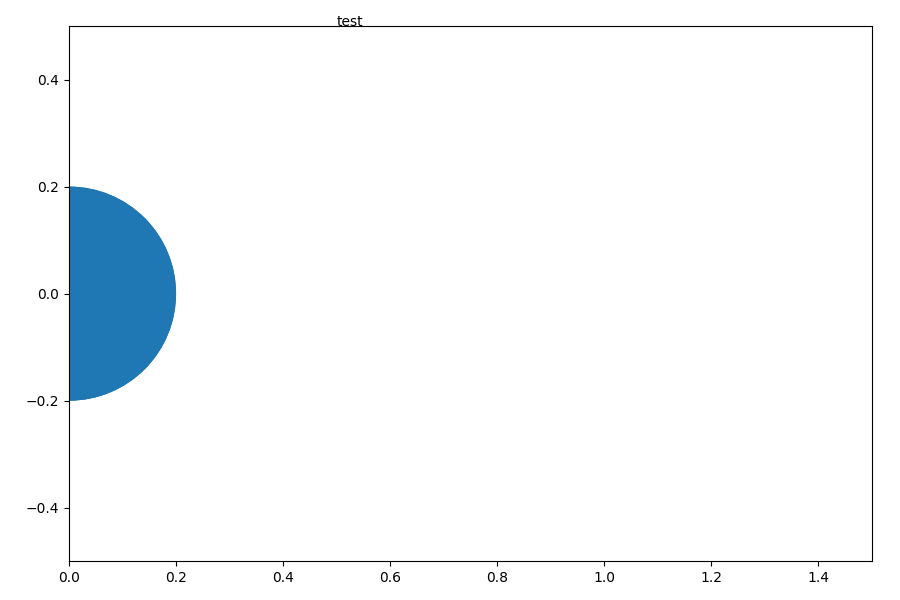

In [6]:
plt.close('all')

animation_t, animation_x1, _, animation_x2, *_ = solve_collision(m1, m2, 0.5, v1_0, 1.0, v2_0, R, 2200, dt=0.01, max_t=1.0, stop_after_collision=False)

fig, axes = plt.subplots(figsize=(9, 6))

axes.set_ylim(-0.5, 0.5)
axes.set_xlim(0.0, 1.5)
axes.set_aspect('equal')

body1 = Ellipse((0, 0), 2 * R, 2 * R)
axes.add_patch(body1)

body2 = Ellipse((0, 0), 2 * R, 2 * R)
axes.add_patch(body2)

center_markers, = axes.plot([], [], 'o', color='red', markersize=1)

debug_text = axes.text(0.5, 0.5, 'test')

def precompute_animation_data():
    centers1 = []
    centers2 = []
    widths = []

    for i in range(len(animation_x1)):
        x1 = animation_x1[i]
        x2 = animation_x2[i]
        overlap = max(2 * R - (x2 - x1), 0)

        centers1.append((x1 - overlap / 4, 0))
        centers2.append((x2 + overlap / 4, 0))
        widths.append(2 * R - overlap / 2)

    return centers1, centers2, widths

centers1, centers2, widths = precompute_animation_data()

def animate(frame):
    sample_index = frame % len(animation_x1)

    body1.center = centers1[sample_index]
    body2.center = centers2[sample_index]

    current_width = widths[sample_index]
    body1.width = current_width
    body2.width = current_width

    center_markers.set_data([animation_x1[sample_index], animation_x2[sample_index]], [0, 0])

    debug_text.set_text(f't = {animation_t[sample_index]:.3f} с\nкадр = {frame}')

    return body1, body2, center_markers, debug_text

try:
    anim.event_source.stop()
except NameError:
    pass
anim = FuncAnimation(fig, animate,
                    frames=len(animation_t),
                    interval=16,
                    blit=True,
                    repeat=True,
                    cache_frame_data=False)

plt.tight_layout()
plt.show()

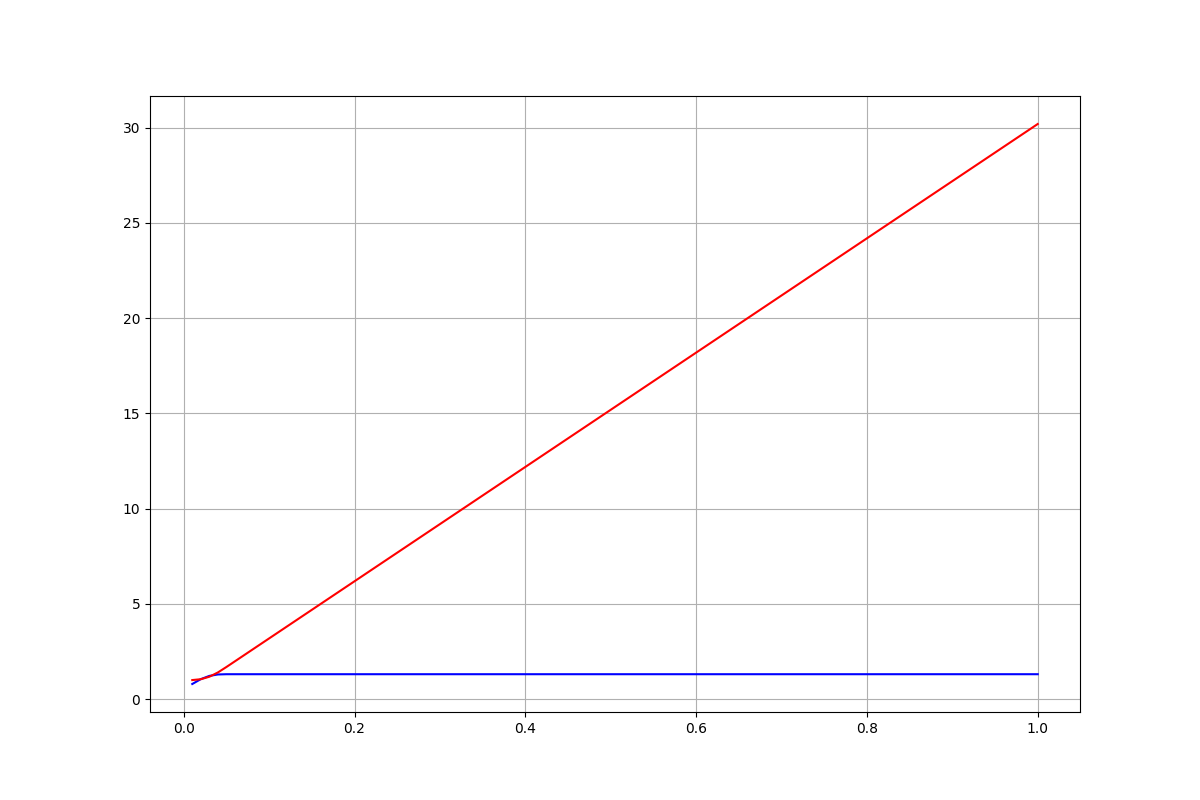

In [7]:
plt.figure(figsize=(12, 8))

plt.plot(animation_t, animation_x1, 'b-')
plt.plot(animation_t, animation_x2, 'r-')

plt.grid(True)
plt.show()

In [8]:
print("=== СТОЛКНОВЕНИЕ ДВУХ ОДИНАКОВЫХ ШАРОВ ===")


t, x1, v1, x2, v2, F, K1, K2, E_potential = solve_collision(m1, m2, x1_0, v1_0, x2_0, v2_0, R, k)
t_gz, x1_gz, v1_gz, x2_gz, v2_gz, F_gz, K1_gz, K2_gz, E_potential_gz = solve_collision(m1, m2, x1_0, v1_0, x2_0, v2_0, R, k, 1.5)

v1_theory = ((m1 - m2) * v1_0 + 2 * m2 * v2_0) / (m1 + m2)
v2_theory = (2 * m1 * v1_0 + (m2 - m1) * v2_0) / (m1 + m2)

print(f"\nТеоретические скорости:")
print(f"v1={v1_theory:.3f} м/с, v2={v2_theory:.3f} м/с")
print(f"Погрешности: {abs(v1[-1] - v1_theory):.3f}, {abs(v2[-1] - v2_theory):.3f} м/с")


=== СТОЛКНОВЕНИЕ ДВУХ ОДИНАКОВЫХ ШАРОВ ===
Начальные условия:
Расстояние: 0.410 м
Скорости: v1=30.0 м/с, v2=0.0 м/с
Столкновение началось на t=0.0004 с

Результаты:
Столкновение произошло: True
Максимальная сила: 6706.8 Н
Конечные скорости: v1=0.000 м/с, v2=30.000 м/с
Время моделирования: 0.010 с
Начальные условия:
Расстояние: 0.410 м
Скорости: v1=30.0 м/с, v2=0.0 м/с
Столкновение началось на t=0.0004 с

Результаты:
Столкновение произошло: True
Максимальная сила: 12590.6 Н
Конечные скорости: v1=-0.000 м/с, v2=30.000 м/с
Время моделирования: 0.013 с

Теоретические скорости:
v1=0.000 м/с, v2=30.000 м/с
Погрешности: 0.000, 0.000 м/с


In [9]:
print(f"\n=== СТОЛКНОВЕНИЕ СО СТЕНКОЙ ===")

t_w, x1_w, v1_w, x2_w, v2_w, F_w, K1_w, K2_w, E_potential_w = solve_collision(m1, m_wall, x1_0, v1_0, x2_0, v2_0, R, k)
t_w_gz, x1_w_gz, v1_w_gz, x2_w_gz, v2_w_gz, F_w_gz, K1_w_gz, K2_w_gz, E_potential_w_gz = solve_collision(m1, m_wall, x1_0, v1_0, x2_0, v2_0, R, k, 1.5)

print(f"Теоретическая скорость от стенки: {-v1_0:.3f} м/с")
print(f"Погрешность: {abs(v1_w[-1] - (-v1_0)):.3f} м/с")




=== СТОЛКНОВЕНИЕ СО СТЕНКОЙ ===
Начальные условия:
Расстояние: 0.410 м
Скорости: v1=30.0 м/с, v2=0.0 м/с
Столкновение началось на t=0.0004 с

Результаты:
Столкновение произошло: True
Максимальная сила: 9486.9 Н
Конечные скорости: v1=-30.000 м/с, v2=0.000 м/с
Время моделирования: 0.010 с
Начальные условия:
Расстояние: 0.410 м
Скорости: v1=30.0 м/с, v2=0.0 м/с
Столкновение началось на t=0.0004 с

Результаты:
Столкновение произошло: True
Максимальная сила: 16613.4 Н
Конечные скорости: v1=-30.000 м/с, v2=0.000 м/с
Время моделирования: 0.017 с
Теоретическая скорость от стенки: -30.000 м/с
Погрешность: 0.000 м/с


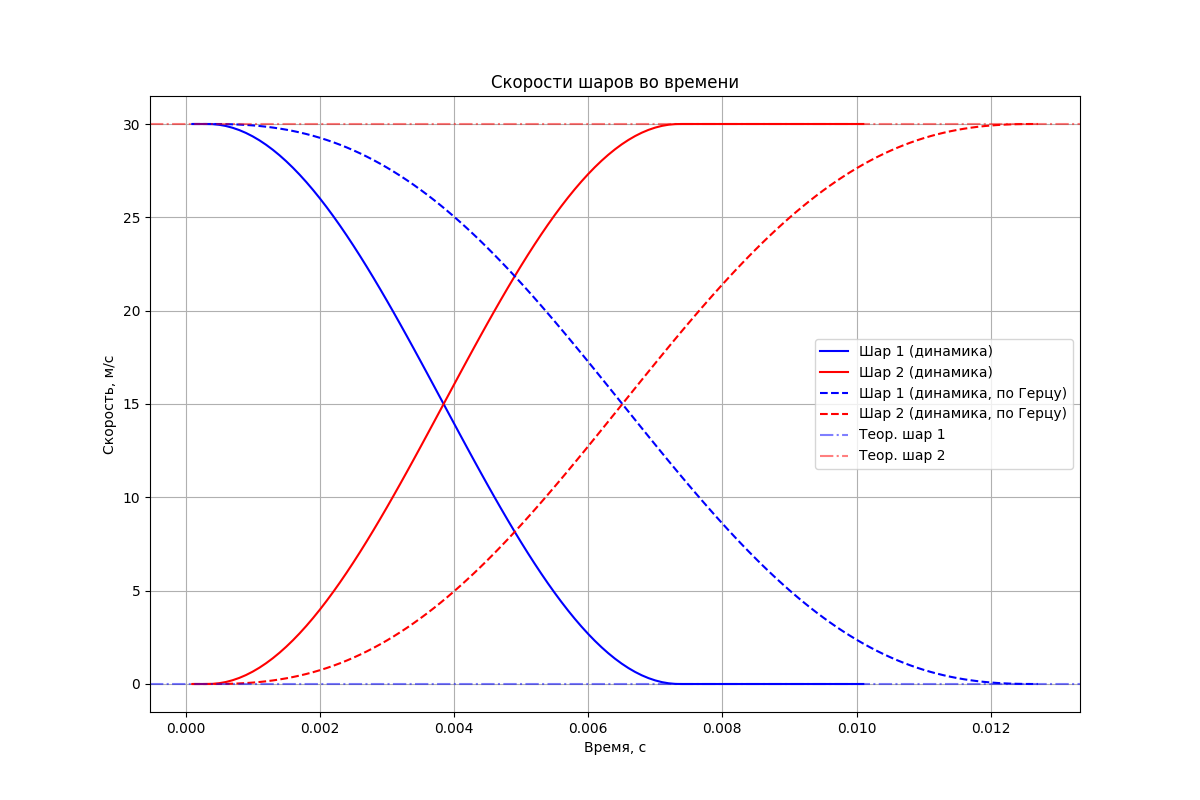

In [10]:
# 1. Графики скоростей
plt.figure(figsize=(12, 8))

plt.plot(t, v1, 'b-', label='Шар 1 (динамика)')
plt.plot(t, v2, 'r-', label='Шар 2 (динамика)')

plt.plot(t_gz, v1_gz, 'b--', label='Шар 1 (динамика, по Герцу)')
plt.plot(t_gz, v2_gz, 'r--', label='Шар 2 (динамика, по Герцу)')
# plt.plot(t_w, v1_w, 'g-', label='Шар о стенку (динамика)')

# # Теоретические значения
plt.axhline(y=v1_theory, color='b', linestyle='-.', alpha=0.5, label='Теор. шар 1')
plt.axhline(y=v2_theory, color='r', linestyle='-.', alpha=0.5, label='Теор. шар 2')
# plt.axhline(y=-3, color='g', linestyle='--', alpha=0.5, label='Теор. от стенки')

plt.title('Скорости шаров во времени')
plt.xlabel('Время, с')
plt.ylabel('Скорость, м/с')
plt.legend()
plt.grid(True)
plt.show()

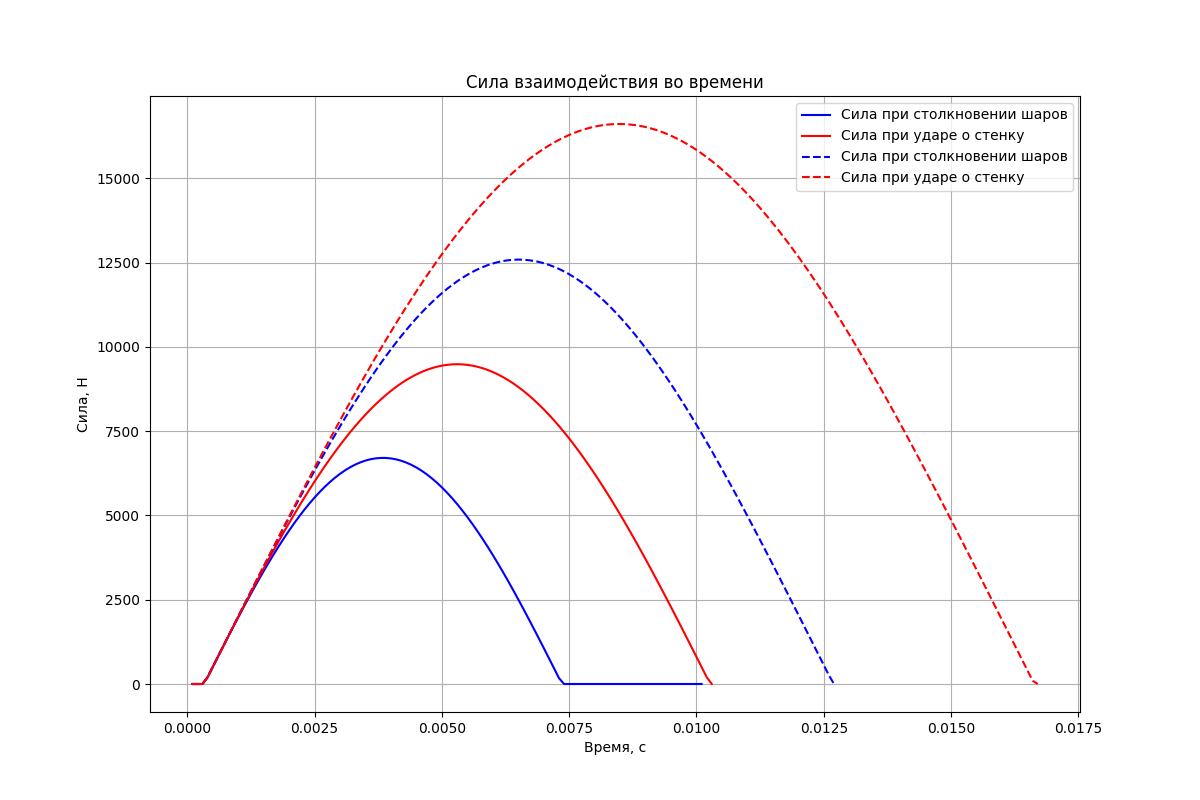

In [11]:
plt.figure(figsize=(12, 8))

plt.plot(t, F, 'b-', label='Сила при столкновении шаров')
plt.plot(t_w, F_w, 'r-', label='Сила при ударе о стенку')
plt.plot(t_gz, F_gz, 'b--', label='Сила при столкновении шаров')
plt.plot(t_w_gz, F_w_gz, 'r--', label='Сила при ударе о стенку')

plt.title('Сила взаимодействия во времени')
plt.xlabel('Время, с')
plt.ylabel('Сила, Н')
plt.legend()
plt.grid(True)
plt.show()

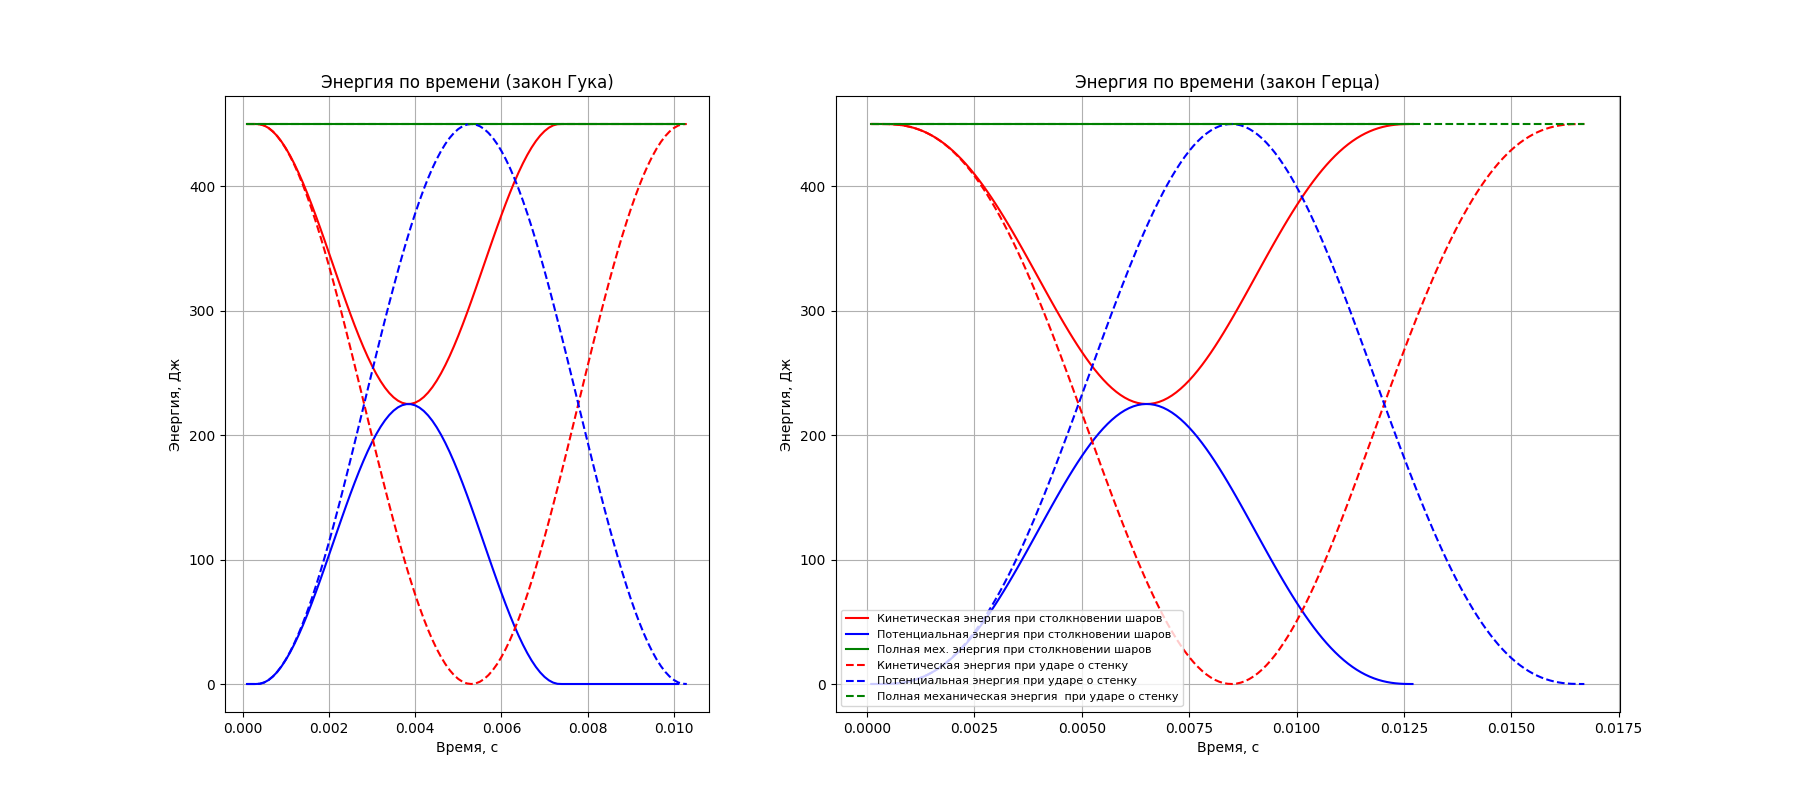

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [max(t[-1], t_w[-1]), max(t_gz[-1], t_w_gz[-1])]})

axes[0].plot(t, K1 + K2, 'r-', label='Кинетическая энергия при столкновении шаров')
axes[0].plot(t, E_potential, 'b-', label='Потенциальная энергия при столкновении шаров')
axes[0].plot(t, K1 + K2 + E_potential, 'g-', label='Полная мех. энергия при столкновении шаров')
axes[0].plot(t_w, K1_w + K2_w, 'r--', label='Кинетическая энергия при ударе о стенку')
axes[0].plot(t_w, E_potential_w, 'b--', label='Потенциальная энергия при ударе о стенку')
axes[0].plot(t_w, K1_w + K2_w + E_potential_w, 'g--', label='Полная механическая энергия  при ударе о стенку')

axes[1].plot(t_gz, K1_gz + K2_gz, 'r-', label='Кинетическая энергия при столкновении шаров')
axes[1].plot(t_gz, E_potential_gz, 'b-', label='Потенциальная энергия при столкновении шаров')
axes[1].plot(t_gz, K1_gz + K2_gz + E_potential_gz, 'g-', label='Полная мех. энергия при столкновении шаров')
axes[1].plot(t_w_gz, K1_w_gz + K2_w_gz, 'r--', label='Кинетическая энергия при ударе о стенку')
axes[1].plot(t_w_gz, E_potential_w_gz, 'b--', label='Потенциальная энергия при ударе о стенку')
axes[1].plot(t_w_gz, K1_w_gz + K2_w_gz + E_potential_w_gz, 'g--', label='Полная механическая энергия  при ударе о стенку')

axes[0].set_title('Энергия по времени (закон Гука)')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Энергия, Дж')
# axes[0].legend(loc='lower left', fontsize=8)
axes[0].grid(True)

axes[1].set_title('Энергия по времени (закон Герца)')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Энергия, Дж')
axes[1].legend(loc='lower left', fontsize=8)
axes[1].grid(True)

plt.show()